In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import kagglehub

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print(path)

/root/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3


In [3]:
df = pd.read_csv(path + "/DailyDelhiClimateTrain.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [5]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [6]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [7]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

df.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day,dayofweek,is_weekend
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1,1,1,0
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1,2,2,0
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1,3,3,0
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1,4,4,0
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1,5,5,1


In [9]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of rows:", len(df))

Start date: 2013-01-01 00:00:00
End date: 2017-01-01 00:00:00
Number of rows: 1462


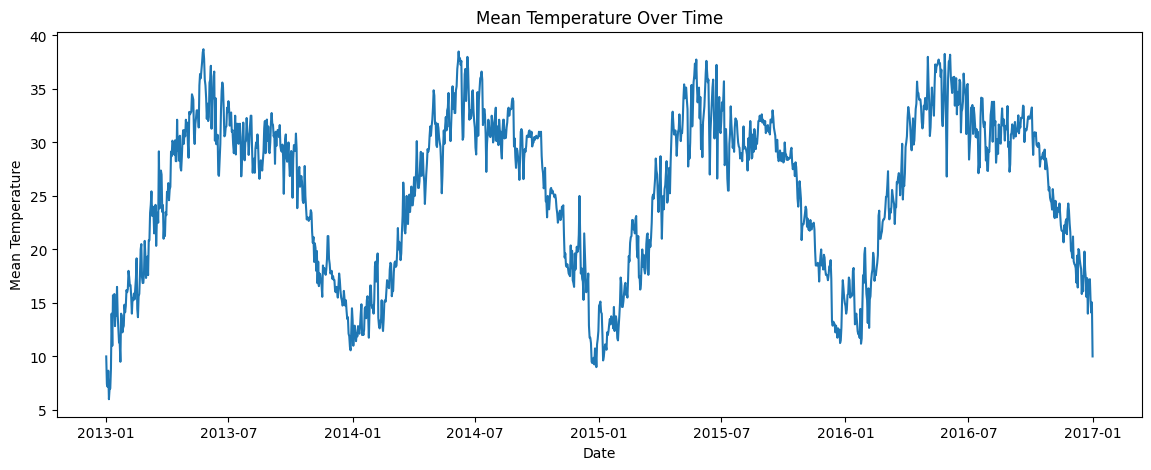

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["meantemp"])
plt.title("Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.show()

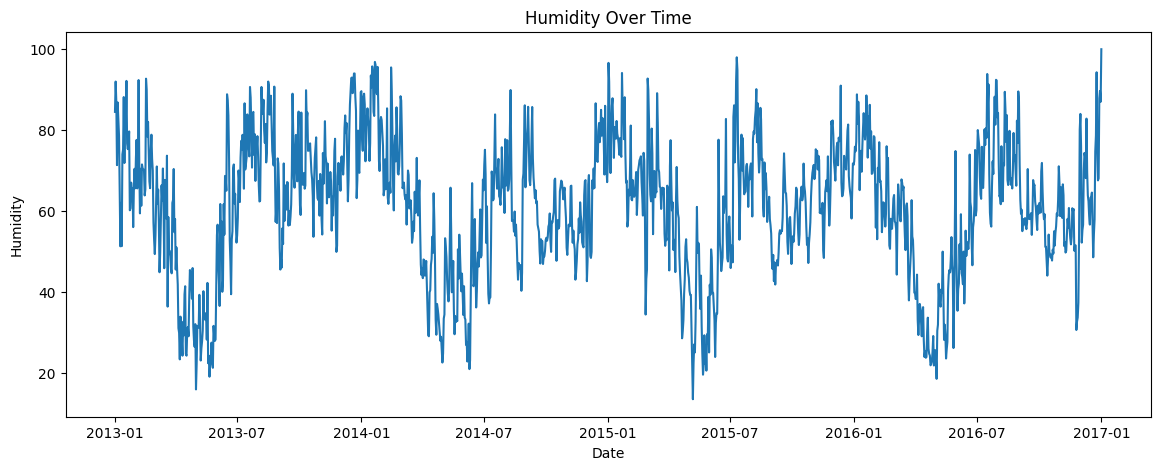

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["humidity"])
plt.title("Humidity Over Time")
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.show()

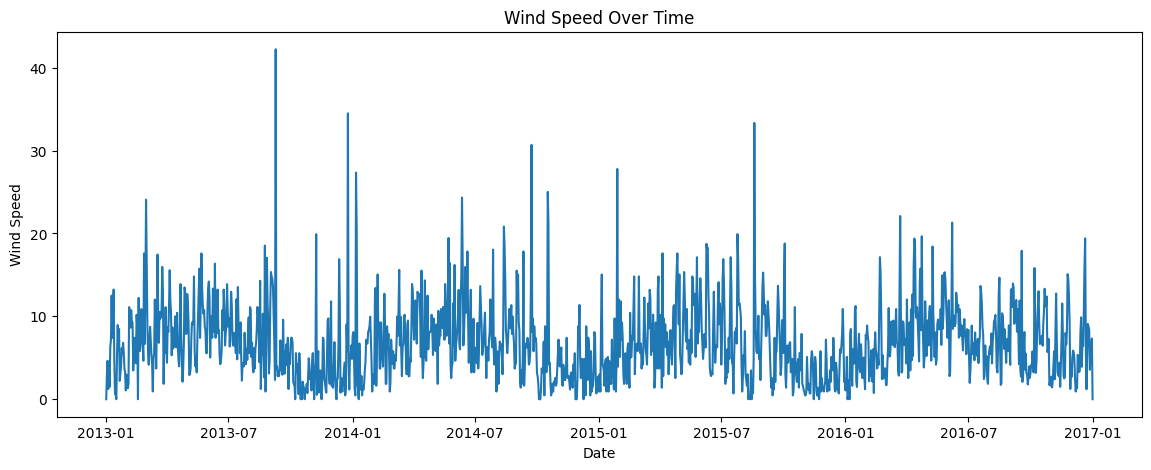

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["wind_speed"])
plt.title("Wind Speed Over Time")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.show()

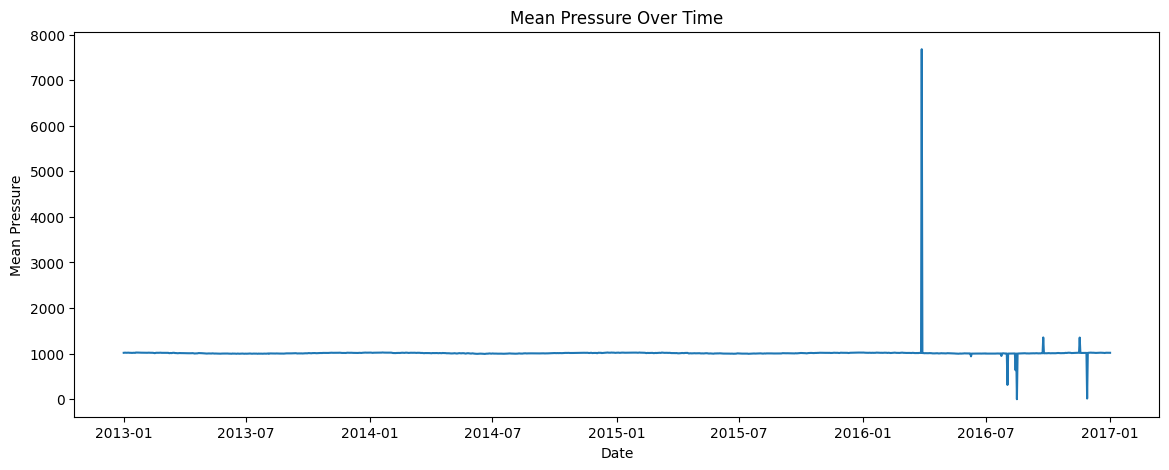

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["meanpressure"])
plt.title("Mean Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Pressure")
plt.show()

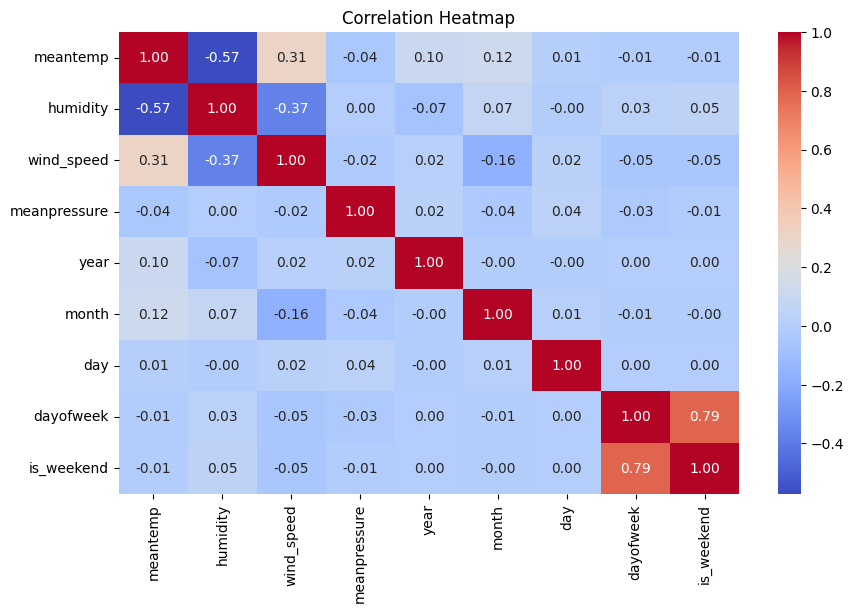

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
features = ["year", "month", "day", "dayofweek", "is_weekend"]
features

['year', 'month', 'day', 'dayofweek', 'is_weekend']

In [16]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1169
Test size: 293


In [17]:
def train_and_compare(target):
    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    mae_lr = mean_absolute_error(y_test, pred_lr)
    mse_lr = mean_squared_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    r2_lr = r2_score(y_test, pred_lr)

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, pred_rf)
    mse_rf = mean_squared_error(y_test, pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    r2_rf = r2_score(y_test, pred_rf)

    if r2_rf > r2_lr:
        best_model = rf
        best_name = "Random Forest"
        best_pred = pred_rf
        best_mae = mae_rf
        best_mse = mse_rf
        best_rmse = rmse_rf
        best_r2 = r2_rf
    else:
        best_model = lr
        best_name = "Linear Regression"
        best_pred = pred_lr
        best_mae = mae_lr
        best_mse = mse_lr
        best_rmse = rmse_lr
        best_r2 = r2_lr

    print(f"===== {target.upper()} =====")
    print("Linear Regression R²:", r2_lr)
    print("Random Forest R²:", r2_rf)
    print("Best Model:", best_name)
    print()

    return {
        "target": target,
        "lr_model": lr,
        "rf_model": rf,
        "best_model": best_model,
        "best_model_name": best_name,
        "y_test": y_test,
        "best_pred": best_pred,
        "lr_r2": r2_lr,
        "rf_r2": r2_rf,
        "best_mae": best_mae,
        "best_mse": best_mse,
        "best_rmse": best_rmse,
        "best_r2": best_r2
    }

In [18]:
temp_results = train_and_compare("meantemp")
humidity_results = train_and_compare("humidity")
wind_results = train_and_compare("wind_speed")
pressure_results = train_and_compare("meanpressure")

===== MEANTEMP =====
Linear Regression R²: -1.0874942676980162
Random Forest R²: 0.693422516362747
Best Model: Random Forest

===== HUMIDITY =====
Linear Regression R²: -0.12545659680652554
Random Forest R²: 0.2632702115309963
Best Model: Random Forest

===== WIND_SPEED =====
Linear Regression R²: -0.24506000131683314
Random Forest R²: -0.3888912509073459
Best Model: Linear Regression

===== MEANPRESSURE =====
Linear Regression R²: -0.00017319948250027473
Random Forest R²: 0.0003091363784798462
Best Model: Random Forest



In [19]:
comparison_df = pd.DataFrame({
    "Target": ["Temperature", "Humidity", "Wind Speed", "Pressure"],
    "Best Model": [
        temp_results["best_model_name"],
        humidity_results["best_model_name"],
        wind_results["best_model_name"],
        pressure_results["best_model_name"]
    ],
    "MAE": [
        temp_results["best_mae"],
        humidity_results["best_mae"],
        wind_results["best_mae"],
        pressure_results["best_mae"]
    ],
    "MSE": [
        temp_results["best_mse"],
        humidity_results["best_mse"],
        wind_results["best_mse"],
        pressure_results["best_mse"]
    ],
    "RMSE": [
        temp_results["best_rmse"],
        humidity_results["best_rmse"],
        wind_results["best_rmse"],
        pressure_results["best_rmse"]
    ],
    "R2": [
        temp_results["best_r2"],
        humidity_results["best_r2"],
        wind_results["best_r2"],
        pressure_results["best_r2"]
    ]
})

comparison_df

,Target,Best Model,MAE,MSE,RMSE,R2
0,Temperature,Random Forest,2.489658,9.814676,3.132838,0.693423
1,Humidity,Random Forest,11.791555,213.142994,14.599418,0.263270
2,Wind Speed,Linear Regression,3.408171,20.205413,4.495043,-0.245060
3,Pressure,Random Forest,38.005614,161581.947741,401.972571,0.000309


In [20]:
best_overall_row = comparison_df.loc[comparison_df["R2"].idxmax()]
best_overall_row

,0
Target,Temperature
Best Model,Random Forest
MAE,2.489658
MSE,9.814676
RMSE,3.132838
R2,0.693423


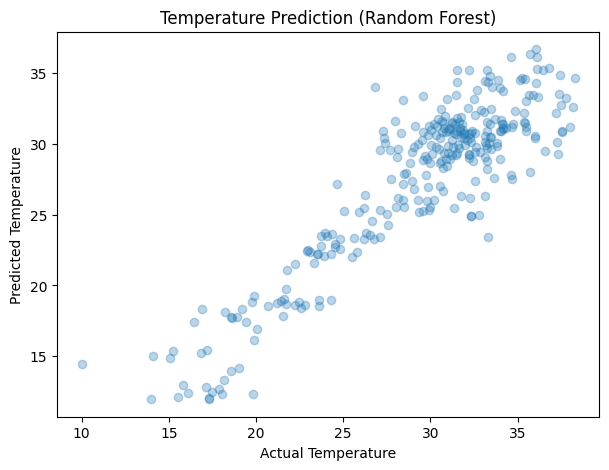

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(temp_results["y_test"], temp_results["best_pred"], alpha=0.3)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title(f"Temperature Prediction ({temp_results['best_model_name']})")
plt.show()

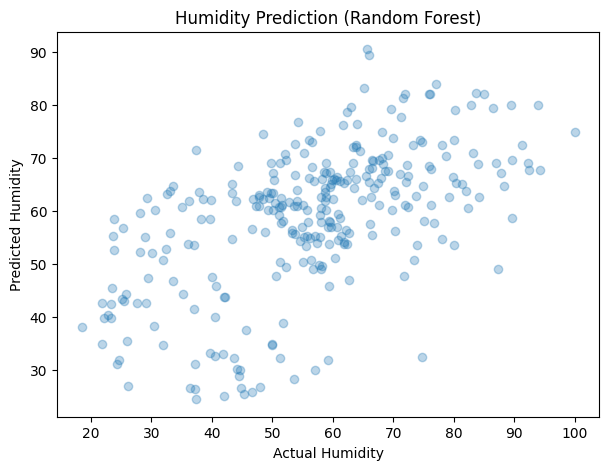

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(humidity_results["y_test"], humidity_results["best_pred"], alpha=0.3)
plt.xlabel("Actual Humidity")
plt.ylabel("Predicted Humidity")
plt.title(f"Humidity Prediction ({humidity_results['best_model_name']})")
plt.show()

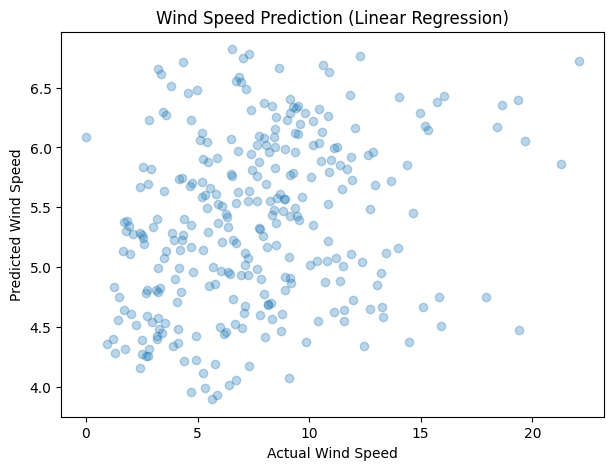

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(wind_results["y_test"], wind_results["best_pred"], alpha=0.3)
plt.xlabel("Actual Wind Speed")
plt.ylabel("Predicted Wind Speed")
plt.title(f"Wind Speed Prediction ({wind_results['best_model_name']})")
plt.show()

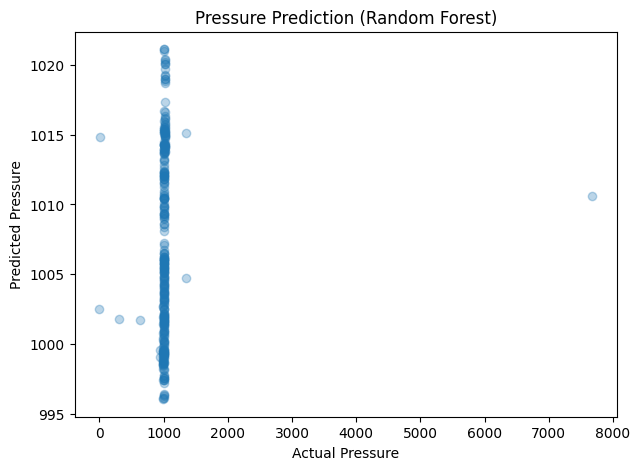

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(pressure_results["y_test"], pressure_results["best_pred"], alpha=0.3)
plt.xlabel("Actual Pressure")
plt.ylabel("Predicted Pressure")
plt.title(f"Pressure Prediction ({pressure_results['best_model_name']})")
plt.show()

In [25]:
def predict_future(date_str):
    dt = pd.to_datetime(date_str)

    input_data = pd.DataFrame([{
        "year": dt.year,
        "month": dt.month,
        "day": dt.day,
        "dayofweek": dt.dayofweek,
        "is_weekend": 1 if dt.dayofweek in [5, 6] else 0
    }])

    predictions = {
        "Temperature": temp_results["best_model"].predict(input_data)[0],
        "Humidity": humidity_results["best_model"].predict(input_data)[0],
        "Wind Speed": wind_results["best_model"].predict(input_data)[0],
        "Pressure": pressure_results["best_model"].predict(input_data)[0]
    }

    return predictions

In [26]:
predict_future("2017-04-25")

{'Temperature': np.float64(30.445714285714285),
 'Humidity': np.float64(38.86214285714286),
 'Wind Speed': np.float64(6.035212204815252),
 'Pressure': np.float64(1005.6525)}

In [27]:
predict_future("2017-12-01")

{'Temperature': np.float64(18.46),
 'Humidity': np.float64(68.045),
 'Wind Speed': np.float64(3.7437639120915946),
 'Pressure': np.float64(1015.0975)}

In [28]:
joblib.dump(temp_results["best_model"], "temp_model.pkl")
joblib.dump(humidity_results["best_model"], "humidity_model.pkl")
joblib.dump(wind_results["best_model"], "wind_model.pkl")
joblib.dump(pressure_results["best_model"], "pressure_model.pkl")

print("Best models saved successfully.")

Best models saved successfully.


In [29]:
comparison_df.to_csv("comparison_metrics.csv", index=False)
print("Saved: comparison_metrics.csv")

Saved: comparison_metrics.csv


In [30]:
dashboard_df = df.copy()
dashboard_df.to_csv("climate_dashboard_data.csv", index=False)
print("Saved: climate_dashboard_data.csv")

Saved: climate_dashboard_data.csv


In [31]:
from google.colab import files

files.download("temp_model.pkl")
files.download("humidity_model.pkl")
files.download("wind_model.pkl")
files.download("pressure_model.pkl")
files.download("comparison_metrics.csv")
files.download("climate_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>